# Application to real data

This notebook applies the discussed methods in real data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from cmdstanpy import cmdstan_path, CmdStanModel, set_cmdstan_path, install_cmdstan

import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import arviz as az
import scienceplots
plt.style.use('science')

import sys
import os
sys.path.append('../scripts/python')
from tqdm.auto import tqdm

from parameter_estimation import BivariateBeta

Some pre sets:

In [3]:
folder = '../data/covid_tests_data/'
filter_func = lambda i: lambda x: float(re.findall('[0-9].[0-9][0-9]', x.replace(',', '.'))[i])

stanfile = os.path.join('..', 'scripts', 'stan', 'bivariate-beta-model-lognormal.stan')
model_lognormal = CmdStanModel(stan_file=stanfile, cpp_options={'STAN_THREADS': True})

stanfile = os.path.join('..', 'scripts', 'stan', 'bivariate-beta-model-gamma.stan')
model_gamma = CmdStanModel(stan_file=stanfile, cpp_options={'STAN_THREADS': True})

In [4]:
stanfile = os.path.join('..', 'scripts', 'stan', 'logit-bivariate-model.stan')
model_logit = CmdStanModel(stan_file=stanfile, cpp_options={'STAN_THREADS': True})

# Accuracy of diagnostic tests registered by ANVISA for COVID-19

A documentary investigation was carried out utilizing the information provided by manufacturers during their registration with Anvisa. 
The diagnostic tests recorded with Anvisa up to June 23, 2020, during the data collection period, were scrutinized through the use of the following link: [https://consultas.anvisa.gov.br/#/saude/q/?nomeTecnico=coronav%C3%ADrus](https://consultas.anvisa.gov.br/#/saude/q/?nomeTecnico=coronav%C3%ADrus).

The data that was registered with Anvisa during the time of registration was retrieved from the Agency's website, specifically from the General Management of Health Product Technology (GGTPS) for in vitro diagnosis. 
To present the data in a structured format, a standard table created by the authors was employed, gathering essential information such as: i) company/importer; ii) manufacturer/country; iii) sample; iv) whether it was classified as a quick test v) Anvisa registration number; vi) sensitivity/specificity data presented by the manufacturer. 
The information provided by the manufacturers during their registration with Anvisa was then used to generate graphs displaying the sensitivity and specificity of the diagnostic tests.

The data provided by the manufacturers were plotted in the figures presented to illustrate the IgG and/or IgM sensitivity and specificity of the tests:

a) immunochromatographic with blood sample (whole blood, venous whole blood, whole blood via digital puncture or dried blood), human serum or plasma;

b) immunochromatographic with secretion nasopharyngeal swab and oropharyngeal swab;

c) immunoassay with blood sample (whole blood, venous whole blood, whole blood via finger prick or dried blood), human serum or plasma;

d) immunoassay with nasopharyngeal swab and oropharyngeal swab secretion sample;

e) qualitative or semi-qualitative detection with blood sample

In [76]:
tables = [pd.read_csv(folder+'raw/table_a.csv'),
          pd.read_csv(folder+'raw/table_b.csv'),
          pd.read_csv(folder+'raw/table_c.csv'),
          pd.read_csv(folder+'raw/table_d.csv'),
          pd.read_csv(folder+'raw/table_e.csv'),
          pd.read_csv(folder+'raw/table_pcr_a.csv'),
          pd.read_csv(folder+'raw/table_pcr_b.csv'),
          pd.read_csv(folder+'raw/table_pcr_c.csv'),
         ]

letters = ['a', 'b', 'c', 'd', 'e', 'a_pcr', 'b_pcr', 'c_pcr']
for i in range(8):

    tables[i]['sensitivity']          = tables[i]['Sensitivity [95% CI]'].apply(filter_func(0))
    tables[i]['sensitivity_ci_lower'] = tables[i]['Sensitivity [95% CI]'].apply(filter_func(1))
    tables[i]['sensitivity_ci_upper'] = tables[i]['Sensitivity [95% CI]'].apply(filter_func(2))
    tables[i]['specificity']          = tables[i]['Specificity [95% CI]'].apply(filter_func(0))
    tables[i]['specificity_ci_lower'] = tables[i]['Specificity [95% CI]'].apply(filter_func(1))
    tables[i]['specificity_ci_upper'] = tables[i]['Specificity [95% CI]'].apply(filter_func(2))
    tables[i]['type']                 = letters[i]
    
    del tables[i]['Sensitivity [95% CI]']
    del tables[i]['Specificity [95% CI]']
    
df = pd.concat(tables)

In [77]:
df

,Study,TP,FP,FN,TN,sensitivity,sensitivity_ci_lower,sensitivity_ci_upper,specificity,specificity_ci_lower,specificity_ci_upper,type
0,10071770900,312,1,49,234,0.86,0.82,0.90,1.00,0.98,1.00,a
1,10071770901,46,3,2,47,0.96,0.86,0.99,0.94,0.83,0.99,a
2,10210410105,90,3,3,124,0.97,0.91,0.99,0.98,0.93,1.00,a
3,10310030208,171,12,12,514,0.93,0.89,0.97,0.98,0.96,0.99,a
4,10342880015,23,2,1,49,0.96,0.79,1.00,0.96,0.87,1.00,a
...,...,...,...,...,...,...,...,...,...,...,...,...
11,80867150018,209,10,0,370,1.00,0.98,1.00,0.97,0.95,0.99,a_pcr
12,80954880134,3,0,0,98,1.00,0.29,1.00,1.00,0.96,1.00,a_pcr
0,10009010357,60,0,0,60,1.00,0.94,1.00,1.00,0.94,1.00,b_pcr
1,10223400001,10,0,0,14,1.00,0.69,1.00,1.00,0.77,1.00,b_pcr


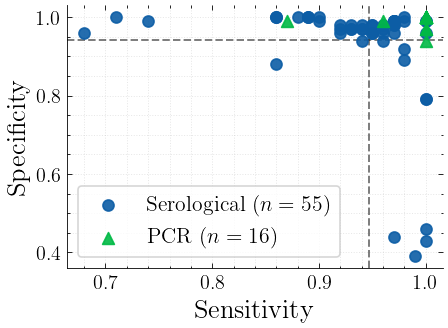

In [78]:
mask_pcr = df['type'].str.contains('pcr', case=False, na=False)
mask_ser = ~mask_pcr

m1 = df['sensitivity'].mean()
m2 = df['specificity'].mean()

plt.figure(figsize=(4,3), dpi=120)

# mean reference lines
plt.axvline(m1, linestyle='--', linewidth=1.2, color='black', alpha=0.5, zorder=2)
plt.axhline(m2, linestyle='--', linewidth=1.2, color='black', alpha=0.5, zorder=2)

# serological/immunoassay
plt.scatter(df.loc[mask_ser, 'sensitivity'],
            df.loc[mask_ser, 'specificity'],
            marker='o', s=44, alpha=0.9,
            label=rf"Serological ($n={mask_ser.sum()}$)", zorder=3)

# PCR/molecular
plt.scatter(df.loc[mask_pcr, 'sensitivity'],
            df.loc[mask_pcr, 'specificity'],
            marker='^', s=50, alpha=0.9,
            label=rf"PCR ($n={mask_pcr.sum()}$)", zorder=3)

plt.xlabel('Sensitivity', fontsize=16); plt.ylabel('Specificity', fontsize=16)
#plt.title('Sensitivity vs Specificity (Anvisa registrations)')
plt.grid(True, which='both', linestyle=':', linewidth=0.6, alpha=0.3)
plt.legend(loc='lower left', frameon=True, fontsize=13)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()

plt.savefig('../figures/anvisa_scatter.pdf', bbox_inches='tight')
plt.show()

In [79]:
df.describe()

,Study,TP,FP,FN,TN,sensitivity,sensitivity_ci_lower,sensitivity_ci_upper,specificity,specificity_ci_lower,specificity_ci_upper
count,7.100000e+01,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000
mean,5.591396e+10,115.394366,13.971831,7.183099,191.676056,0.946901,0.835070,0.976479,0.942958,0.881127,0.962676
std,3.390722e+10,97.261427,45.681810,11.856656,212.390192,0.065500,0.174076,0.037037,0.132432,0.154064,0.113187
min,1.000901e+10,2.000000,0.000000,0.000000,5.000000,0.680000,0.160000,0.820000,0.390000,0.320000,0.440000
25%,1.034136e+10,49.000000,0.500000,0.000000,60.000000,0.930000,0.820000,0.970000,0.960000,0.890000,0.990000
50%,8.025802e+10,92.000000,2.000000,3.000000,124.000000,0.970000,0.890000,0.990000,0.980000,0.930000,1.000000
75%,8.086715e+10,169.000000,9.000000,7.500000,241.000000,1.000000,0.925000,1.000000,1.000000,0.960000,1.000000
max,8.198451e+10,422.000000,297.000000,49.000000,1364.000000,1.000000,0.980000,1.000000,1.000000,0.990000,1.000000


In [80]:
distribution = BivariateBeta()

x = df.sensitivity.values
y = df.specificity.values

rng = np.random.default_rng(seed=13)
x[x==1] -= rng.uniform(1e-6, 3e-2, size=((x==1).sum()))
y[y==1] -= rng.uniform(1e-6, 3e-2, size=((y==1).sum()))

m1 = np.mean(x)
m2 = np.mean(y)
v1 = np.var(x, ddof=0)
v2 = np.var(y, ddof=0)
rho = np.corrcoef(x, y)[0,1]

moments = [m1, m2, v1, v2, rho]
moments

[0.9420970923630471,
 0.9380590063055545,
 0.0038019554751918803,
 0.016814723513834093,
 -0.1734887564556066]

In [81]:
m1*(1-m1)/v1 - m2*(1-m2)/v2

10.892360834354331

Estimating through the method of moments:

In [82]:
alpha_hat1 = distribution.method_moments_estimator_1(x, y)
BivariateBeta(alpha_hat1).moments()

array([ 0.94209709,  0.93805901,  0.00380196,  0.00404967, -0.06370542])

In [83]:
alpha_hat4 = distribution.method_moments_estimator_4(x, y)
BivariateBeta(alpha_hat4).moments()

array([ 0.9028705 ,  0.89900275,  0.01023546,  0.01059745, -0.10993528])

Frequentist diagnostics

In [84]:
distribution.marginal_diagnostic(x,y)

(2.1208826997261165, 0.03393167489003806)

Since $p$-value $< 0.05$, it indicates strong evidence against the null hypothesis that the data comes from the bivariate beta distribution and the marginal distributions do not obey the necessary relation.

In [85]:
distribution.positive_diagnostic_diagnostic(x,y)

-0.006180713599634512

In [86]:
# rho interval
-(min(m1*m2, (1-m1)*(1-m2)))/(np.sqrt(m1*m2*(1-m1)*(1-m2))), (min(m1, m2) - m1*m2)/(np.sqrt(m1*m2*(1-m1)*(1-m2)))

(-0.06370541659036864, 0.9647801273230383)

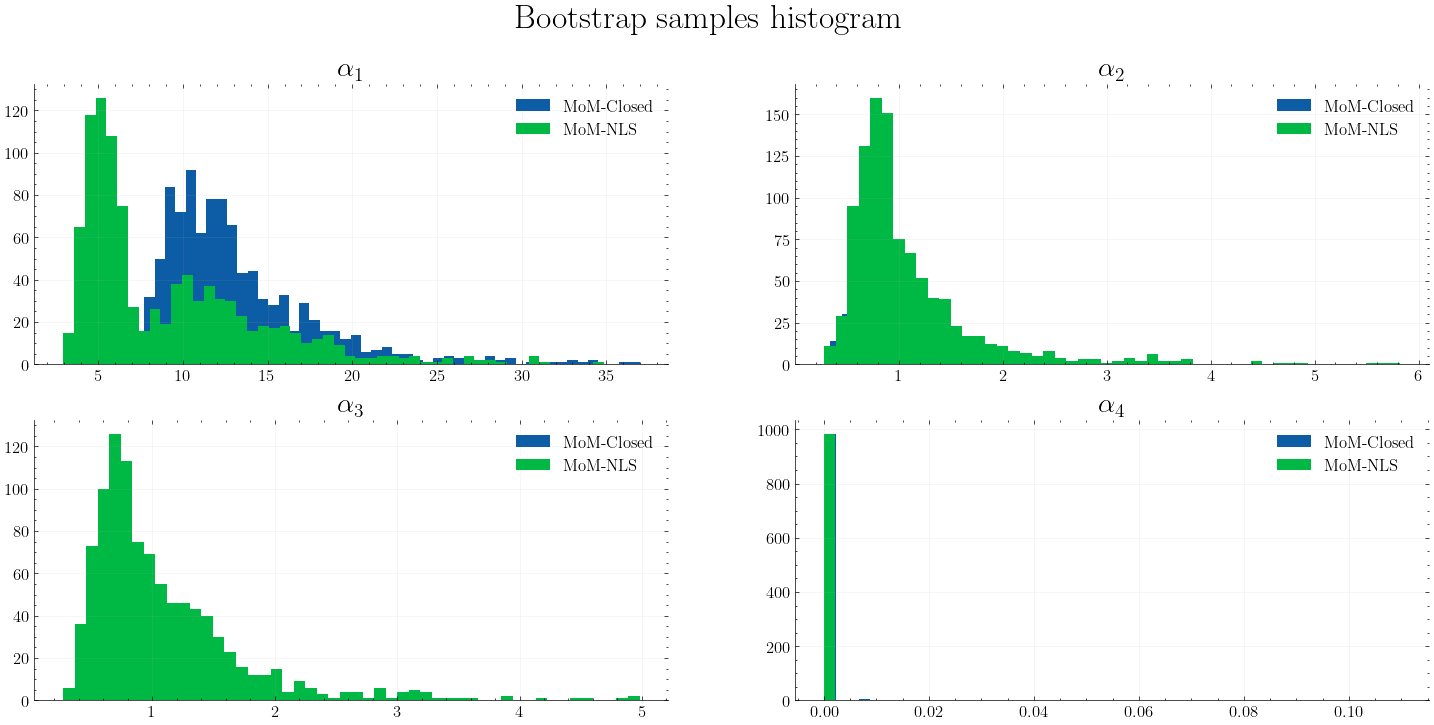

In [87]:
bootstrap_samples_1 = distribution.bootstrap_method(x, y, B=1000, method=distribution.method_moments_estimator_1)
bootstrap_samples_4 = distribution.bootstrap_method(x, y, B=1000, method=distribution.method_moments_estimator_4)

fig, ax = plt.subplots(2,2,figsize=(18,8))
fig.suptitle('Bootstrap samples histogram', fontsize=24)
for k in range(4):
    i = k // 2
    j = k % 2
    ax[i,j].hist(bootstrap_samples_1[k,:], bins=50, label='MoM-Closed')
    ax[i,j].hist(bootstrap_samples_4[k,:], bins=50, label='MoM-NLS')
    ax[i,j].set_title(r'$\alpha_{}$'.format(k+1), fontsize=20)
    ax[i,j].legend(fontsize=12)
plt.show()

In [88]:
a = np.array([1, 1, 1, 1])

data = {'n': x.shape[0], 'a': a, 'xy': np.column_stack([x, y]), 's_mu': 4, 's_sd': 1, 'kappa': 4, 'lambda': 1}
model_fit = model_lognormal.sample(data=data, iter_warmup=2000, iter_sampling=2000, chains=4, adapt_delta=0.99, seed=372189)

12:06:44 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

12:06:55 - cmdstanpy - INFO - CmdStan done processing.


In [89]:
idata = az.from_cmdstanpy(posterior=model_fit)
df = az.summary(idata, hdi_prob=0.95, stat_funcs={"median": np.median}).loc[[f'alpha[{i}]' for i in range(4)]]
df

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
alpha[0],6.442,1.016,4.490,8.479,0.015,0.011,4519.0,5345.0,1.0,6.401
alpha[1],0.230,0.042,0.151,0.313,0.001,0.000,2488.0,4059.0,1.0,0.227
alpha[2],0.358,0.052,0.263,0.460,0.001,0.001,5815.0,6185.0,1.0,0.355
alpha[3],0.274,0.052,0.174,0.375,0.001,0.001,2249.0,3427.0,1.0,0.271


In [90]:
az.bfmi(idata)

array([0.57892394, 0.55578036, 0.56367147, 0.60386661])

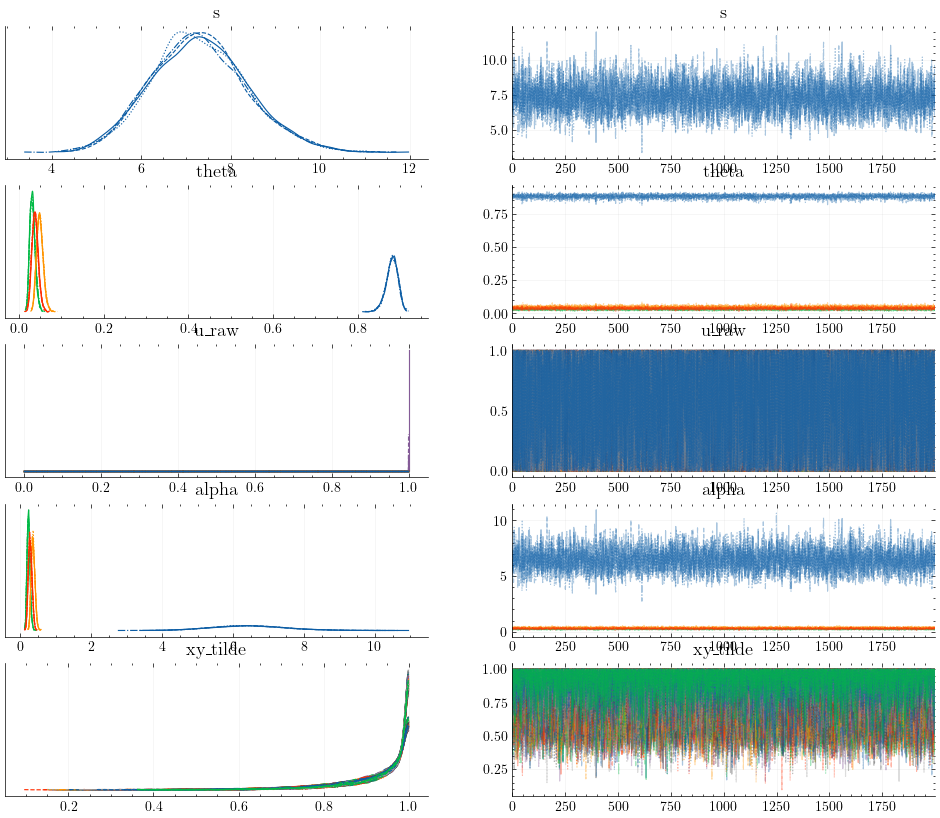

In [91]:
az.plot_trace(idata)
plt.show()

In [92]:
alpha_hat5 = df['mean'].values
BivariateBeta(alpha_hat5).moments()

array([0.91347207, 0.93099671, 0.00951841, 0.00773625, 0.44265764])

In [93]:
alpha_hat6 = df['median'].values
BivariateBeta(alpha_hat6).moments()

array([0.91370278, 0.93134822, 0.00955294, 0.00774639, 0.44271086])

In [94]:
moments = np.zeros((model_fit.alpha.shape[0], 5))
for i in range(model_fit.alpha.shape[0]):
    moments[i,:] = BivariateBeta(model_fit.alpha[i,:]).moments()

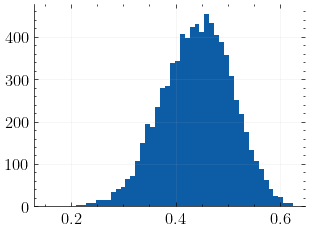

In [95]:
plt.hist(moments[:,-1], bins=50)
plt.show()

In [96]:
np.mean(moments[:,-1] < 0.2)

0.0005

In [97]:
moments.mean(axis=0)

array([0.91244604, 0.93018517, 0.00986731, 0.0080296 , 0.44045359])

In [98]:
np.median(moments, axis=0)

array([0.9132959 , 0.93072471, 0.00956863, 0.00779601, 0.44318785])

## Comparing the models

In [99]:
def build_stan_data(x, y, use_priors=1):
    return {'n': x.shape[0], 'm': x.shape[0], 'xy': np.column_stack([x, y]).astype(float), 'use_priors': int(use_priors), 
            's_sigma1': 2, 's_sigma2': 2, 'tau': 5}

def extract_params_optimize(fit):
    mu = fit.stan_variable('mu')
    sigma1 = float(fit.stan_variable('sigma1'))
    sigma2 = float(fit.stan_variable('sigma2'))
    rho = float(fit.stan_variable('rho'))
    return np.r_[mu, sigma1, sigma2, rho]

def bln_bootstrap_mle(model_logit, x, y, B=200, seed=2421512):
    rng = np.random.default_rng(seed)
    n = len(x)
    params_boot = np.zeros((B, 5), dtype=float)
    idx_boot = np.zeros((B, n), dtype=int)
    for b in tqdm(range(B), desc="BLN bootstrap (optimize)", leave=False):
        idx = rng.choice(n, size=n, replace=True)
        idx_boot[b] = idx
        data_b = build_stan_data(x[idx], y[idx], use_priors=0)
        fit_b = model_logit.optimize(data=data_b, show_console=False)
        params_boot[b] = extract_params_optimize(fit_b)
    return params_boot, idx_boot

def bln_bayes_sample(model_logit, x, y, chains=4, draws=1000, seed=534523):
    data_bayes = build_stan_data(x, y, use_priors=1)
    fit = model_logit.sample(
        data=data_bayes,
        chains=chains,
        parallel_chains=min(chains, os.cpu_count() or 1),
        iter_sampling=draws,
        iter_warmup=max(500, draws//2),
        seed=seed,
        show_progress=True,
    )
    return fit

from scipy.special import expit
def bln_moments(mu1, mu2, sigma1, sigma2, rho, T=200000, seed=123):
    rng = np.random.default_rng(seed)
    Sigma = np.array([
        [sigma1**2, rho * sigma1 * sigma2],
        [rho * sigma1 * sigma2, sigma2**2]
    ])
    Z = rng.multivariate_normal(mean=[mu1, mu2], cov=Sigma, size=T)

    X = expit(Z[:, 0])
    Y = expit(Z[:, 1])

    m1 = X.mean()
    m2 = Y.mean()
    v1 = X.var(ddof=0)
    v2 = Y.var(ddof=0)
    rho_xy = np.corrcoef(X, Y)[0, 1]

    return np.array([m1, m2, v1, v2, rho_xy])

In [100]:
B_BOOT = 500

bln_boot_params, bln_boot_indices = bln_bootstrap_mle(model_logit, x, y, B=B_BOOT, seed=2032125)

BLN bootstrap (optimize):   0%|          | 0/500 [00:00<?, ?it/s]

12:07:05 - cmdstanpy - INFO - Chain [1] start processing
12:07:05 - cmdstanpy - INFO - Chain [1] done processing
12:07:05 - cmdstanpy - INFO - Chain [1] start processing
12:07:05 - cmdstanpy - INFO - Chain [1] done processing
12:07:05 - cmdstanpy - INFO - Chain [1] start processing
12:07:05 - cmdstanpy - INFO - Chain [1] done processing
12:07:05 - cmdstanpy - INFO - Chain [1] start processing
12:07:05 - cmdstanpy - INFO - Chain [1] done processing
12:07:05 - cmdstanpy - INFO - Chain [1] start processing
12:07:05 - cmdstanpy - INFO - Chain [1] done processing
12:07:05 - cmdstanpy - INFO - Chain [1] start processing
12:07:05 - cmdstanpy - INFO - Chain [1] done processing
12:07:05 - cmdstanpy - INFO - Chain [1] start processing
12:07:05 - cmdstanpy - INFO - Chain [1] done processing
12:07:05 - cmdstanpy - INFO - Chain [1] start processing
12:07:05 - cmdstanpy - INFO - Chain [1] done processing
12:07:05 - cmdstanpy - INFO - Chain [1] start processing
12:07:05 - cmdstanpy - INFO - Chain [1]

In [101]:
bln_fit = bln_bayes_sample(model_logit, x, y, chains=4, draws=2000, seed=2023215)

bln_idata = az.from_cmdstanpy(
    posterior=bln_fit,
    log_likelihood='log_lik',
    posterior_predictive='xy_tilde',
    coords={'obs_id': np.arange(len(x))},
    dims={'log_lik': ['obs_id'], 'xy_tilde': ['ppc_id', 'dim']},
)

12:07:19 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

12:07:20 - cmdstanpy - INFO - CmdStan done processing.
12:07:20 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: logit_bivariate_model_model_namespace::log_prob: Sigma is not symmetric. Sigma[1,2] = -inf, but Sigma[2,1] = -inf (in '/Users/lmm122/Documents/github/bivariate-beta/scripts/stan/logit-bivariate-model.stan', line 27, column 4 to column 24)
	Exception: logit_bivariate_model_model_namespace::log_prob: Sigma is not symmetric. Sigma[1,2] = inf, but Sigma[2,1] = inf (in '/Users/lmm122/Documents/github/bivariate-beta/scripts/stan/logit-bivariate-model.stan', line 27, column 4 to column 24)
	Exception: logit_bivariate_model_model_namespace::log_prob: Sigma is not symmetric. Sigma[1,2] = -inf, but Sigma[2,1] = -inf (in '/Users/lmm122/Documents/github/bivariate-beta/scripts/stan/logit-bivariate-model.stan', line 27, column 4 to column 24)
	Exception: logit_bivariate_model_model_namespace::log_prob: Sigma is not symmetric. Sigma[1,2] = inf, but Sigma[2,1] = inf (in '

In [102]:
sample_moments = lambda x, y: np.array([np.mean(x), np.mean(y), np.var(x, ddof=0), np.var(y, ddof=0), np.corrcoef(x,y)[0,1]])

def tail_event_indicators(x, y, thr=0.9):
    return (x > thr) & (y > thr)

def brier_log_scores(ind, p, eps=1e-12):
    ind = ind.astype(float)
    p = np.clip(p, eps, 1 - eps)
    brier = float(np.mean((ind - p)**2))
    logsc = float(np.mean(ind * np.log(p) + (1 - ind) * np.log(1 - p)))
    return brier, logsc

def simulate_tail_prob_bibeta(alpha, T=20000, thr=0.9, rng=None):
    rng = np.random.default_rng(seed=84921) if rng is None else rng
    U = rng.dirichlet(alpha, size=T)
    X = U[:,0] + U[:,1]
    Y = U[:,0] + U[:,2]
    return float(np.mean((X > thr) & (Y > thr)))

def simulate_tail_prob_bln(params, T=20000, thr=0.9, rng=None):
    rng = np.random.default_rng(84921) if rng is None else rng
    mu1, mu2, sigma1, sigma2, rho = params
    Sigma = np.array([
        [sigma1**2, rho * sigma1 * sigma2],
        [rho * sigma1 * sigma2, sigma2**2]
    ])

    Z = rng.multivariate_normal(mean=[mu1, mu2], cov=Sigma, size=T)
    X = expit(Z[:, 0])
    Y = expit(Z[:, 1])

    return np.mean((X > thr) & (Y > thr))
    
def tail_from_posterior_predictive(idata, thr=0.9, take=1000):
    xy = idata.posterior_predictive['xy_tilde']
    arr = np.asarray(xy.stack(sample=('chain','draw')).transpose('sample','ppc_id','dim'))
    if arr.shape[0] > take:
        idx = np.random.default_rng(5324154).choice(arr.shape[0], size=take, replace=False)
        arr = arr[idx]
    p_draws = []
    for a in arr:
        X = np.asarray(a[:,0]); Y = np.asarray(a[:,1])
        p_draws.append(float(np.mean((X > thr) & (Y > thr))))
    return np.array(p_draws)

def tail_from_bibeta_bootstrap(bootstrap_alphas, thr=0.9, T=50000, take=200, seed=43532):
    rng = np.random.default_rng(seed)
    B = bootstrap_alphas.shape[0]
    idx = rng.choice(B, size=min(take, B), replace=False)
    p_list = []
    for i in tqdm(idx, desc="Tail from Beta bootstrap", leave=False):
        alpha = np.asarray(bootstrap_alphas[i], dtype=float)
        p_list.append(simulate_tail_prob_bibeta(alpha, T=T, thr=thr, rng=rng))
    return np.array(p_list)

def tail_from_bln_bootstrap(bootstrap_params, thr=0.9, T=50000, take=200, seed=87654):
    rng = np.random.default_rng(seed)
    B = bootstrap_params.shape[0]
    idx = rng.choice(B, size=min(take, B), replace=False)
    p_list = []
    for i in tqdm(idx, desc="Tail from BLN bootstrap", leave=False):
        params = np.asarray(bootstrap_params[i], dtype=float)
        p_list.append(simulate_tail_prob_bln(params, T=T, thr=thr, rng=rng))
    return np.array(p_list)

def bln_ppc_moments_from_idata(idata):
    xy = idata.posterior_predictive['xy_tilde']
    arr = np.asarray(xy.stack(sample=('chain','draw')).transpose('sample','ppc_id','dim'))
    mlist = []
    for a in arr:
        mlist.append(sample_moments(a[:,0], a[:,1]))
    return np.vstack(mlist)

def beta_ppc_moments_from_model_fit(model_fit):
    idata_beta = az.from_cmdstanpy(
        posterior=model_fit,
        log_likelihood='log_lik',
        posterior_predictive='xy_tilde',   # required for PPC moments
        coords={'obs_id': np.arange(len(x))},
        dims={'log_lik': ['obs_id'], 'xy_tilde': ['ppc_id', 'dim']},
    )
    xy = idata_beta.posterior_predictive['xy_tilde']
    arr = np.asarray(xy.stack(sample=('chain','draw')).transpose('sample','ppc_id','dim'))
    mlist = []
    for a in arr:
        mlist.append(sample_moments(a[:,0], a[:,1]))
    return np.vstack(mlist), idata_beta

def z_scores_from_moment_draws(moment_draws, obs_mom):
    mu = moment_draws.mean(axis=0)
    sd = moment_draws.std(axis=0, ddof=1)
    z = (obs_mom - mu) / (sd + 1e-12)
    return z, mu, sd

from scipy.special import gammaln
def pdf_bibeta(x, y, alpha, T=5000, rng=None):
    if not (0 < x < 1 and 0 < y < 1):
        return 0.0
    a1,a2,a3,a4 = alpha
    # bounds of integration
    lb = max(0, x+y-1)
    ub = min(x,y)
    rng = np.random.default_rng() if rng is None else rng
    U = rng.uniform(lb, ub, size=T)
    vals = (U**(a1-1) *
            (x-U)**(a2-1) *
            (y-U)**(a3-1) *
            (1-x-y+U)**(a4-1))
    integral = vals.mean() * (ub - lb)
    # normalization constant
    log_norm = gammaln(a1) + gammaln(a2) + gammaln(a3) + gammaln(a4) - gammaln(a1+a2+a3+a4)
    return integral / np.exp(log_norm)

def loo_logscore_bibeta(x, y, estimator, T=5000, seed=32, B=50, nu=None):
    rng = np.random.default_rng(seed)
    n = len(x)
    loo_scores = []
    for i in tqdm(range(n), leave=False):
        x_minus_i = np.delete(x,i); y_minus_i = np.delete(y,i)
        lp = 0.0
        for b in range(B):
            idx = rng.choice(n-1, size=n-1, replace=True)
            if nu is None:
                alpha_hat = estimator(x_minus_i[idx], y_minus_i[idx])
            else:
                alpha_hat = estimator(x_minus_i[idx], y_minus_i[idx], nu=nu)
            lp += pdf_bibeta(x[i], y[i], alpha_hat, T=T) / B
        loo_scores.append(np.log(lp))
    loo_scores = np.array(loo_scores)
    return loo_scores.mean(), loo_scores

from scipy.special import logit
from scipy.stats import multivariate_normal
def pdf_bln_point(x, y, params):
    mu1, mu2, sigma1, sigma2, rho = params
    if not (0 < x < 1 and 0 < y < 1):
        return 0.0
    z1, z2 = logit(x), logit(y)
    cov = [[sigma1**2, rho*sigma1*sigma2],
           [rho*sigma1*sigma2, sigma2**2]]
    mvn_pdf = multivariate_normal.pdf([z1, z2], mean=[mu1, mu2], cov=cov, allow_singular=True)
    jac = 1.0 / (x*(1-x)*y*(1-y))
    return mvn_pdf * jac

def loo_logscore_bln(x, y, model_logit, seed=65432, B=50):
    rng = np.random.default_rng(seed)
    n = len(x)
    loo_scores = []
    for i in tqdm(range(n), leave=False):
        xy_minus_i = np.column_stack([np.delete(x,i), np.delete(y,i)])
        data_i = {'n': n-1, 'm': 0, 's_sigma1': 2.0, 's_sigma2': 2.0, 'tau': 5.0, 'use_priors': 0}
        lp = 0.0
        for b in range(B):
            idx = rng.choice(n-1, size=n-1, replace=True)
            data_i['xy'] = xy_minus_i[idx]
            fit_i = model_logit.optimize(data=data_i, seed=int(rng.integers(1e9)))
            mu, rho = fit_i.stan_variable('mu'), fit_i.stan_variable('rho')
            sigma1, sigma2 = fit_i.stan_variable('sigma1'), fit_i.stan_variable('sigma2')
            params = (mu[0], mu[1], sigma1, sigma2, rho)
            lp += pdf_bln_point(x[i], y[i], params) / B
        loo_scores.append(np.log(lp))
    loo_scores = np.array(loo_scores)
    return loo_scores.mean(), loo_scores

In [103]:
obs_mom = sample_moments(x, y)
beta_moment_draws, beta_idata = beta_ppc_moments_from_model_fit(model_fit)

loo_res = az.loo(beta_idata, pointwise=True)
results = {}
results['beta_bayes'] = {
    'elpd': {
        'elpd_loo': float(loo_res.elpd_loo),
        'se': float(loo_res.se),
        'p_loo': float(loo_res.p_loo),
        'loo_i': loo_res.loo_i.values,
    },
    'moments': {},
}

results['beta_bayes']['moments']['Z'], \
results['beta_bayes']['moments']['mean'], \
results['beta_bayes']['moments']['sd'] = z_scores_from_moment_draws(beta_moment_draws, obs_mom)

# Tail distribution, Brier/Log scores
p_tail_draws = tail_from_posterior_predictive(beta_idata, thr=0.9, take=1000)
results['beta_bayes']['tail'] = {
    'p_mean': float(p_tail_draws.mean()),
    'p_sd':   float(p_tail_draws.std(ddof=1)),
    'p_draws': p_tail_draws,
}

/opt/homebrew/Caskroom/miniconda/base/envs/stan/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [104]:
bln_moment_draws = bln_ppc_moments_from_idata(bln_idata)

loo_res = az.loo(bln_idata, pointwise=True)
results['bln_bayes'] = {
    'elpd': {
        'elpd_loo': float(loo_res.elpd_loo),
        'se': float(loo_res.se),
        'p_loo': float(loo_res.p_loo),
        'loo_i': loo_res.loo_i.values,
    },
    'moments': {},
}

results['bln_bayes']['moments']['Z'], \
results['bln_bayes']['moments']['mean'], \
results['bln_bayes']['moments']['sd'] = z_scores_from_moment_draws(bln_moment_draws, obs_mom)

p_tail_draws_bln = tail_from_posterior_predictive(bln_idata, thr=0.9, take=1000)
results['bln_bayes']['tail'] = {
    'p_mean': float(p_tail_draws_bln.mean()),
    'p_sd':   float(p_tail_draws_bln.std(ddof=1)),
    'p_draws': p_tail_draws_bln,
}

/opt/homebrew/Caskroom/miniconda/base/envs/stan/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [105]:
mom_list = []
for a in bootstrap_samples_1.T:
    mom_list.append(BivariateBeta(a).moments())
mom_draws = np.asarray(mom_list, dtype=float)

mean_logscore_bibeta, loo_scores_bibeta = loo_logscore_bibeta(x, y, distribution.method_moments_estimator_1, seed=654321, T=20000, nu=1e-8)
results['mom_closed'] = {
    'elpd': {
        'elpd_loo': float(loo_scores_bibeta.sum()),
        'se': float(loo_scores_bibeta.std(ddof=1) / np.sqrt(len(loo_scores_bibeta))),
        'p_loo': None,
        'loo_i': loo_scores_bibeta,
    },
    'moments': {},
}

Z, mu_mom, sd_mom = z_scores_from_moment_draws(mom_draws, obs_mom)
results['mom_closed']['moments'] = {'Z': Z, 'mean': mu_mom, 'sd': sd_mom}

p_tail_draws_m1 = tail_from_bibeta_bootstrap(bootstrap_samples_1.T, thr=0.9, T=40000, take=1000)
results['mom_closed']['tail'] = {
    'p_mean': float(p_tail_draws_m1.mean()),
    'p_sd':   float(p_tail_draws_m1.std(ddof=1)),
    'p_draws': p_tail_draws_m1,
}

  0%|          | 0/71 [00:00<?, ?it/s]

Tail from Beta bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

In [106]:
mom_list = []
for a in bootstrap_samples_4.T:
    mom_list.append(BivariateBeta(a).moments())
mom_draws = np.asarray(mom_list, dtype=float)

mean_logscore_bibeta, loo_scores_bibeta = loo_logscore_bibeta(x, y, distribution.method_moments_estimator_4, seed=654321)
results['mom_nls'] = {
    'elpd': {
        'elpd_loo': float(loo_scores_bibeta.sum()),
        'se': float(loo_scores_bibeta.std(ddof=1) / np.sqrt(len(loo_scores_bibeta))),
        'p_loo': None,
        'loo_i': loo_scores_bibeta,
    },
    'moments': {},
}

Z, mu_mom, sd_mom = z_scores_from_moment_draws(mom_draws, obs_mom)
results['mom_nls']['moments'] = {'Z': Z, 'mean': mu_mom, 'sd': sd_mom}

p_tail_draws_m4 = tail_from_bibeta_bootstrap(bootstrap_samples_4.T, thr=0.9, T=40000, take=1000)
results['mom_nls']['tail'] = {
    'p_mean': float(p_tail_draws_m4.mean()),
    'p_sd':   float(p_tail_draws_m4.std(ddof=1)),
    'p_draws': p_tail_draws_m4,
}

  0%|          | 0/71 [00:00<?, ?it/s]

Tail from Beta bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

In [107]:
mle_list = []
for a in bln_boot_params:
    mle_list.append(bln_moments(mu1=a[0], mu2=a[1], sigma1=a[2], sigma2=a[3], rho=a[4]))
mle_draws = np.asarray(mle_list, dtype=float)

mean_logscore_bln, loo_scores_bln = loo_logscore_bln(x, y, model_logit, seed=654321)
results['mle'] = {
    'elpd': {
        'elpd_loo': float(loo_scores_bln.sum()),
        'se': float(loo_scores_bln.std(ddof=1) / np.sqrt(len(loo_scores_bln))),
        'p_loo': None,
        'loo_i': loo_scores_bln,
    },
    'moments': {},
}

Z, mu_mle, sd_mle = z_scores_from_moment_draws(mle_draws, obs_mom)
results['mle']['moments'] = {'Z': Z, 'mean': mu_mle, 'sd': sd_mle}

p_tail_draws = tail_from_bln_bootstrap(bln_boot_params, thr=0.9, T=40000, take=1000)
results['mle']['tail'] = {
    'p_mean': float(p_tail_draws.mean()),
    'p_sd':   float(p_tail_draws.std(ddof=1)),
    'p_draws': p_tail_draws,
}

  0%|          | 0/71 [00:00<?, ?it/s]

12:07:43 - cmdstanpy - INFO - Chain [1] start processing
12:07:43 - cmdstanpy - INFO - Chain [1] done processing
12:07:43 - cmdstanpy - INFO - Chain [1] start processing
12:07:43 - cmdstanpy - INFO - Chain [1] done processing
12:07:43 - cmdstanpy - INFO - Chain [1] start processing
12:07:43 - cmdstanpy - INFO - Chain [1] done processing
12:07:43 - cmdstanpy - INFO - Chain [1] start processing
12:07:43 - cmdstanpy - INFO - Chain [1] done processing
12:07:43 - cmdstanpy - INFO - Chain [1] start processing
12:07:43 - cmdstanpy - INFO - Chain [1] done processing
12:07:43 - cmdstanpy - INFO - Chain [1] start processing
12:07:44 - cmdstanpy - INFO - Chain [1] done processing
12:07:44 - cmdstanpy - INFO - Chain [1] start processing
12:07:44 - cmdstanpy - INFO - Chain [1] done processing
12:07:44 - cmdstanpy - INFO - Chain [1] start processing
12:07:44 - cmdstanpy - INFO - Chain [1] done processing
12:07:44 - cmdstanpy - INFO - Chain [1] start processing
12:07:44 - cmdstanpy - INFO - Chain [1]

Tail from BLN bootstrap:   0%|          | 0/500 [00:00<?, ?it/s]

In [108]:
ind_tail = tail_event_indicators(x, y, thr=0.9).astype(int)

def summarize_brier_log(name, p_draws_or_scalar):
    # use mean p (Bayes) or scalar; Brier/log scores against empirical indicators
    if np.ndim(p_draws_or_scalar) == 0:
        p = float(p_draws_or_scalar)
        b,l = brier_log_scores(ind_tail, p)
        return {'p': p, 'brier': b, 'logscore': l}
    else:
        p_mean = float(np.mean(p_draws_or_scalar))
        b,l = brier_log_scores(ind_tail, p_mean)
        return {'p': p_mean, 'brier': b, 'logscore': l}

summary_rows = []
s = summarize_brier_log('beta_bayes', results['beta_bayes']['tail']['p_draws'])
summary_rows.append(['beta_bayes', s['p'], s['brier'], s['logscore']])

s = summarize_brier_log('bln_bayes', results['bln_bayes']['tail']['p_draws'])
summary_rows.append(['bln_bayes', s['p'], s['brier'], s['logscore']])

s = summarize_brier_log('mom_closed', results['mom_closed']['tail']['p_draws'])
summary_rows.append(['mom_closed', s['p'], s['brier'], s['logscore']])

s = summarize_brier_log('mom_nls', results['mom_nls']['tail']['p_draws'])
summary_rows.append(['mom_nls', s['p'], s['brier'], s['logscore']])

s = summarize_brier_log('mle', results['mle']['tail']['p_draws'])
summary_rows.append(['mle', s['p'], s['brier'], s['logscore']])

summary_df = pd.DataFrame(summary_rows, columns=['model','p_tail','brier','logscore'])
print("Tail-event summary (p_hat, Brier, Log-score):")
display(summary_df)

Tail-event summary (p_hat, Brier, Log-score):


,model,p_tail,brier,logscore
0,beta_bayes,0.592535,0.220767,-0.634100
1,bln_bayes,0.668704,0.209554,-0.610145
2,mom_closed,0.640246,0.212385,-0.616397
3,mom_nls,0.383928,0.310883,-0.817426
4,mle,0.671170,0.209385,-0.609763


In [109]:
elpd_rows = []
elpd_rows.append(['beta_bayes', results['beta_bayes']['elpd']['elpd_loo'], results['beta_bayes']['elpd']['se']])
elpd_rows.append(['bln_bayes', results['bln_bayes']['elpd']['elpd_loo'], results['bln_bayes']['elpd']['se']])
elpd_rows.append(['mom_closed', results['mom_closed']['elpd']['elpd_loo'], results['mom_closed']['elpd']['se']])
elpd_rows.append(['mom_nls', results['mom_nls']['elpd']['elpd_loo'], results['mom_nls']['elpd']['se']])
elpd_rows.append(['mle', results['mle']['elpd']['elpd_loo'], results['mle']['elpd']['se']])
elpd_df = pd.DataFrame(elpd_rows, columns=['model','elpd','elpd_se'])
print("ELPD (Bayes PSIS-LOO and Freq bootstrap-LOO):")
display(elpd_df)

ELPD (Bayes PSIS-LOO and Freq bootstrap-LOO):


,model,elpd,elpd_se
0,beta_bayes,562.082631,25.609230
1,bln_bayes,265.177563,16.716671
2,mom_closed,-510.820405,0.653108
3,mom_nls,-1237.555835,1.793909
4,mle,260.863888,0.241406


In [110]:
def pack_z(model_key, label):
    if model_key not in results: 
        return None
    Z = results[model_key]['moments']['Z']
    mu = results[model_key]['moments']['mean']
    sd = results[model_key]['moments']['sd']
    cols = ['m1','m2','v1','v2','rho']
    row = [label] + list(Z)
    return row, cols

z_rows = []
for key,label in [('beta_bayes','beta_bayes'), ('bln_bayes','bln_bayes'),
                  ('mom_closed','mom_closed'), ('mom_nls','mom_nls'), ('mle', 'mle')]:
    out = pack_z(key, label)
    if out: z_rows.append(out[0]); cols = out[1]
if z_rows:
    z_df = pd.DataFrame(z_rows, columns=['model'] + cols)
    print("Standardized moment misfit Z-scores (observed vs model-implied):")
    display(z_df)

Standardized moment misfit Z-scores (observed vs model-implied):


,model,m1,m2,v1,v2,rho
0,beta_bayes,1.857609,0.542125,-1.647840,2.815063,-3.665074
1,bln_bayes,0.657117,-0.465328,-0.891244,2.398650,-0.648528
2,mom_closed,0.028506,-0.026799,0.030145,9.373159,-8.304545
3,mom_nls,2.227295,1.467181,-1.249244,1.410256,-2.099283
4,mle,0.401042,0.238361,-0.387001,-0.144296,-0.556532


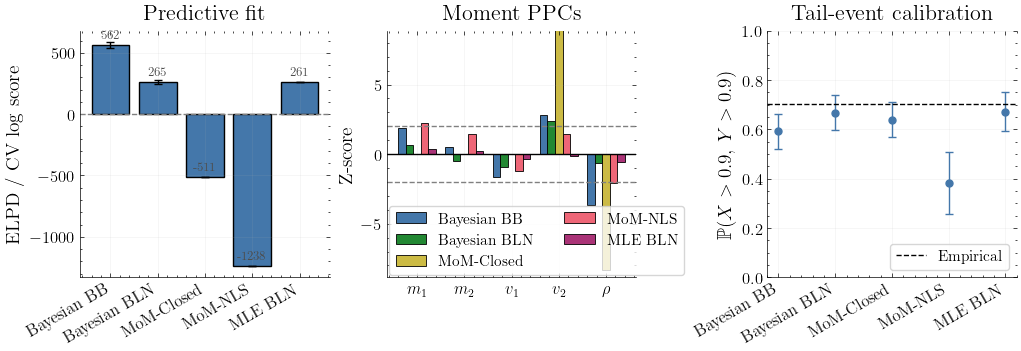

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

# -------------------- styling (paper-friendly) --------------------
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.15,
    "grid.linestyle": "-",
})

# Colorblind-friendly palette (Tol's "bright")
COLORS = ["#4477AA", "#228833", "#CCBB44", "#EE6677", "#AA3377"]

# -------------------- model order & labels --------------------
models = OrderedDict([
    ("beta_bayes", "Bayesian BB"),     # rename here if you prefer another label
    ("bln_bayes",  "Bayesian BLN"),
    ("mom_closed", "MoM-Closed"),
    ("mom_nls",    "MoM-NLS"),
    ("mle",        "MLE BLN"),
])
methods = list(models.values())
xpos = np.arange(len(methods))

# -------------------- pull numbers from your `results` --------------------
elpd_means = [float(results[k]['elpd']['elpd_loo']) for k in models.keys()]
elpd_se    = [float(results[k]['elpd']['se'])       for k in models.keys()]

moment_labels = [r"$m_1$", r"$m_2$", r"$v_1$", r"$v_2$", r"$\rho$"]
moments = { models[k]: np.asarray(results[k]['moments']['Z'], float) for k in models.keys() }

tail_mean = [float(results[k]['tail']['p_mean']) for k in models.keys()]
tail_sd   = [float(results[k]['tail']['p_sd'])   for k in models.keys()]
empirical_tail = float(np.mean((x > 0.9) & (y > 0.9)))

# -------------------- figure --------------------
fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.5), constrained_layout=True)

# ========== Panel 1: Predictive fit ==========
ax = axes[0]
bars = ax.bar(
    xpos, elpd_means, yerr=elpd_se, capsize=3, linewidth=1.0,
    edgecolor="black", color=COLORS[0]
)
ax.axhline(0, color="0.5", linestyle="--", linewidth=1)
ax.set_xticks(xpos)
ax.set_xticklabels(methods, rotation=30, ha="right")
ax.set_ylabel("ELPD / CV log score")
ax.set_title("Predictive fit", pad=8)

# lightly annotate bars (optional; comment out if you prefer clean bars)
for rect in bars:
    ax.annotate(f"{rect.get_height():.0f}",
                xy=(rect.get_x() + rect.get_width()/2, rect.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, color="0.3")

# ========== Panel 2: Moment PPC Z-scores ==========
ax = axes[1]
width = 0.16
for j, method in enumerate(methods):
    zvals = moments[method]
    ax.bar(np.arange(len(moment_labels)) + j*width, zvals,
           width=width, label=method, color=COLORS[j], edgecolor="black", linewidth=0.6)
ax.axhline(0, color="black", linewidth=1)
ax.axhline(2, color="0.5", linestyle="--", linewidth=1)
ax.axhline(-2, color="0.5", linestyle="--", linewidth=1)
ax.set_xticks(np.arange(len(moment_labels)) + 2*width)
ax.set_xticklabels(moment_labels)
ax.set_ylabel("Z-score")
ax.set_title("Moment PPCs", pad=8)
ax.legend(ncol=2, frameon=True, loc="lower left", bbox_to_anchor=(-0.02, -0.02))

# Set a reasonable y-range if extreme MoM Z's appear
z_all = np.concatenate([moments[m] for m in methods])
z_lim = np.percentile(np.abs(z_all), 98)  # robust
ax.set_ylim(-max(2, z_lim), max(2, z_lim))

# ========== Panel 3: Tail-event calibration ==========
ax = axes[2]
ax.errorbar(xpos, tail_mean, yerr=tail_sd, fmt="o", ms=5,
            elinewidth=1.0, capsize=3, color=COLORS[0])
ax.axhline(empirical_tail, color="black", linestyle="--", linewidth=1, label="Empirical")
ax.set_xticks(xpos)
ax.set_xticklabels(methods, rotation=30, ha="right")
ax.set_ylabel(r"$\mathbb{P}(X > 0.9,\, Y > 0.9)$")
# auto y-limits with a little padding
lo = min(min(tail_mean) - 2*max(tail_sd), 0.0)
hi = max(max(tail_mean) + 2*max(tail_sd), 1.0)
ax.set_ylim(max(0.0, lo), min(1.0, hi))
ax.set_title("Tail-event calibration", pad=8)
ax.legend(frameon=True, loc="lower right")

# -------------------- save (vector + raster) --------------------
plt.savefig("../figures/caseB_comparinson.pdf", bbox_inches="tight")
plt.show()

# Study Lymphangeiography

In [37]:
df = pd.read_csv('../data/study_lymphangeiography.csv')

In [44]:
x = df.Sensitivity.values/100
y = df.Specificity.values/100

In [45]:
x.mean()*(1-x.mean())/x.var() - y.mean()*(1-y.mean())/y.var()

-1.6750188382372446

In [47]:
x.shape

(17,)

In [48]:
BivariateBeta().method_moments_estimator_1(x, y)

array([3.2904428 , 0.90459548, 1.60316838, 0.32330843])

In [55]:
BivariateBeta().positive_diagnostic_diagnostic(x,y)

0.0528150995446946

# Vaccination coverage data USA

In [140]:
df = pd.read_csv('../data/Vaccination_Coverage_and_Exemptions_among_Kindergartners_20250909.csv')
DTP_data = df[(df['Vaccine/Exemption'] == 'DTP, DTaP, or DT')&(df['School Year'] == '2024-25')].sort_values(by='Geography')
DTP_data_23 = df[(df['Vaccine/Exemption'] == 'DTP, DTaP, or DT')&(df['School Year'] == '2021-22')].sort_values(by='Geography')
MMR_data = df[(df['Vaccine/Exemption'] == 'MMR')&(df['School Year'] == '2024-25')].sort_values(by='Geography')
Hepatite_data = df[(df['Vaccine/Exemption'] == 'Hepatitis B')&(df['School Year'] == '2024-25')].sort_values(by='Geography')
dataset = pd.DataFrame(index=DTP_data['Geography'], data={'DTP': DTP_data['Estimate (%)'].values, 
                                                          'MMR': MMR_data['Estimate (%)'].values,
                                                          'DTP23': DTP_data_23['Estimate (%)'].values,
                                                          'Hepatite': Hepatite_data['Estimate (%)'].values})
dataset.drop(['Alabama', 'Illinois', 'Maine', 'South Dakota', ], inplace=True)
dataset['DTP'] = np.float64(dataset['DTP'])/100; dataset['MMR'] = np.float64(dataset['MMR'])/100; 
dataset['DTP23'] = np.float64(dataset['DTP23'])/100; dataset['Hepatite'] = np.float64(dataset['Hepatite'])/100; 

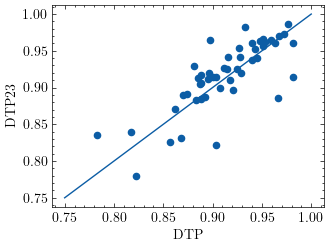

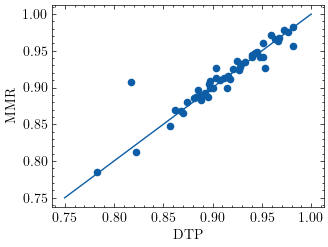

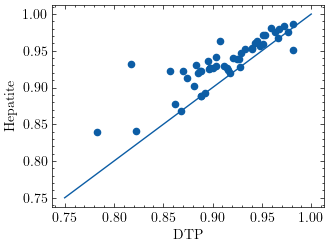

In [141]:
dataset.plot(kind='scatter', x='DTP', y='DTP23')
plt.plot([0.75, 1.0], [0.75, 1.0])
dataset.plot(kind='scatter', x='DTP', y='MMR')
plt.plot([0.75, 1.0], [0.75, 1.0])
dataset.plot(kind='scatter', x='DTP', y='Hepatite')
plt.plot([0.75, 1.0], [0.75, 1.0])

# Share of immunized children

## Fitting the model

In [29]:
df_dtp = pd.read_csv('../data/share-of-children-immunized-dtp3/share-of-children-immunized-dtp3.csv',
                     names=['Entity', 'Code', 'Year', 'Share'], header=0)
df_measles = pd.read_csv('../data/share-of-children-vaccinated-against-measles/share-of-children-vaccinated-against-measles.csv',
                         names=['Entity', 'Code', 'Year', 'Share'], header=0)
df = pd.merge(left=df_dtp, right=df_measles, on=['Entity', 'Code', 'Year'])
df.dropna(inplace=True)
df = df[df['Year'] == 2024]
df['Share_x'] = df['Share_x']/100; df['Share_y'] = df['Share_y']/100

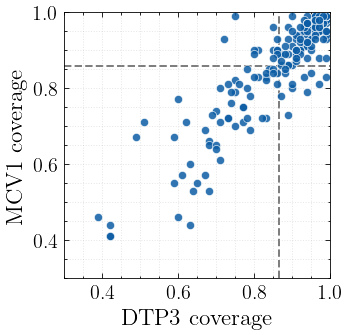

In [30]:
m1 = df['Share_x'].mean()
m2 = df['Share_y'].mean()

plt.figure(figsize=(4,3), dpi=120)

plt.axvline(m1, linestyle='--', linewidth=1.2, color='black', alpha=0.5, zorder=1)
plt.axhline(m2, linestyle='--', linewidth=1.2, color='black', alpha=0.5, zorder=1)

plt.scatter(df['Share_x'],
            df['Share_y'],
            marker='o', s=24, alpha=0.85, zorder=2, edgecolor='white', linewidth=0.4)

plt.xlim(0.3,1)
plt.ylim(0.3,1)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('DTP3 coverage', fontsize=14); plt.ylabel('MCV1 coverage', fontsize=14)
plt.grid(True, which='both', linestyle=':', linewidth=0.6, alpha=0.3)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()

plt.savefig('../figures/share_children_vaccination_dtp3_mcv1.pdf', bbox_inches='tight')
plt.show()

In [32]:
distribution = BivariateBeta()

x = df.Share_x.values
y = df.Share_y.values

m1 = np.mean(x)
m2 = np.mean(y)
v1 = np.var(x, ddof=0)
v2 = np.var(y, ddof=0)
rho = np.corrcoef(x, y)[0,1]

moments = [m1, m2, v1, v2, rho]
moments

[0.8654871794871793,
 0.858871794871795,
 0.016855531886916502,
 0.019965906640368174,
 0.8549303683356746]

Bootstrap correlation

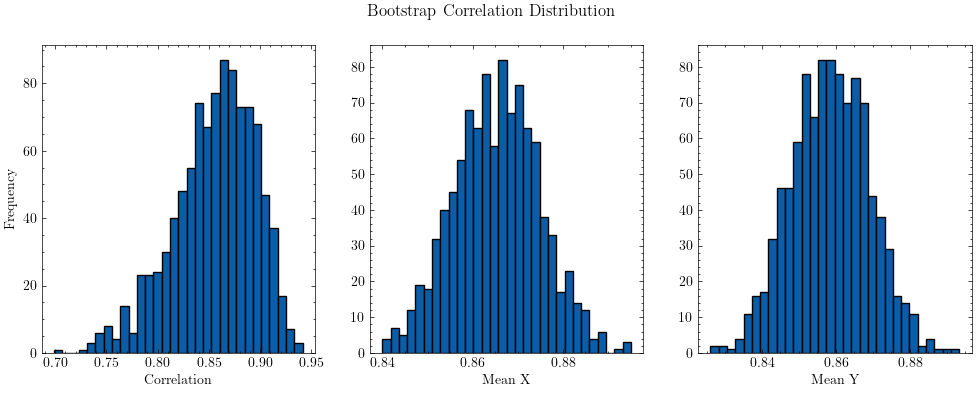

In [33]:
rng = np.random.default_rng(seed=3921)
n_bootstrap = 1000
boot_corrs = []
boot_m1 = []
boot_m2 = []

np.random.randint
for _ in range(n_bootstrap):
    indices = rng.integers(0, len(x), len(x))
    sample_x = x[indices]
    sample_y = y[indices]
    corr = np.corrcoef(sample_x, sample_y)[0, 1]
    boot_m1.append(sample_x.mean())
    boot_m2.append(sample_y.mean())
    boot_corrs.append(corr)

boot_corrs = np.array(boot_corrs)

fig, ax = plt.subplots(1,3,figsize=(12,4))
ax[0].hist(boot_corrs, bins=30, edgecolor="black")
ax[1].hist(boot_m1, bins=30, edgecolor="black")
ax[2].hist(boot_m2, bins=30, edgecolor="black")
ax[0].set_xlabel("Correlation")
ax[1].set_xlabel("Mean X")
ax[2].set_xlabel("Mean Y")
ax[0].set_ylabel("Frequency")
fig.suptitle("Bootstrap Correlation Distribution")
plt.show()

In [34]:
m1*(1-m1)/v1 - m2*(1-m2)/v2

0.835978530629971

In [35]:
alpha_hat1 = distribution.method_moments_estimator_1(x, y)
BivariateBeta(alpha_hat1).moments()

array([0.86548718, 0.85887179, 0.01685553, 0.01754932, 0.85493037])

In [36]:
alpha_hat4 = distribution.method_moments_estimator_4(x, y)
BivariateBeta(alpha_hat4).moments()

array([0.8656228 , 0.85874438, 0.01804914, 0.01882227, 0.85493045])

In [37]:
distribution.marginal_diagnostic(x,y)

(1.13553368070112, 0.2561517782422489)

In [38]:
distribution.positive_diagnostic_diagnostic(x,y)

0.013971304272778554

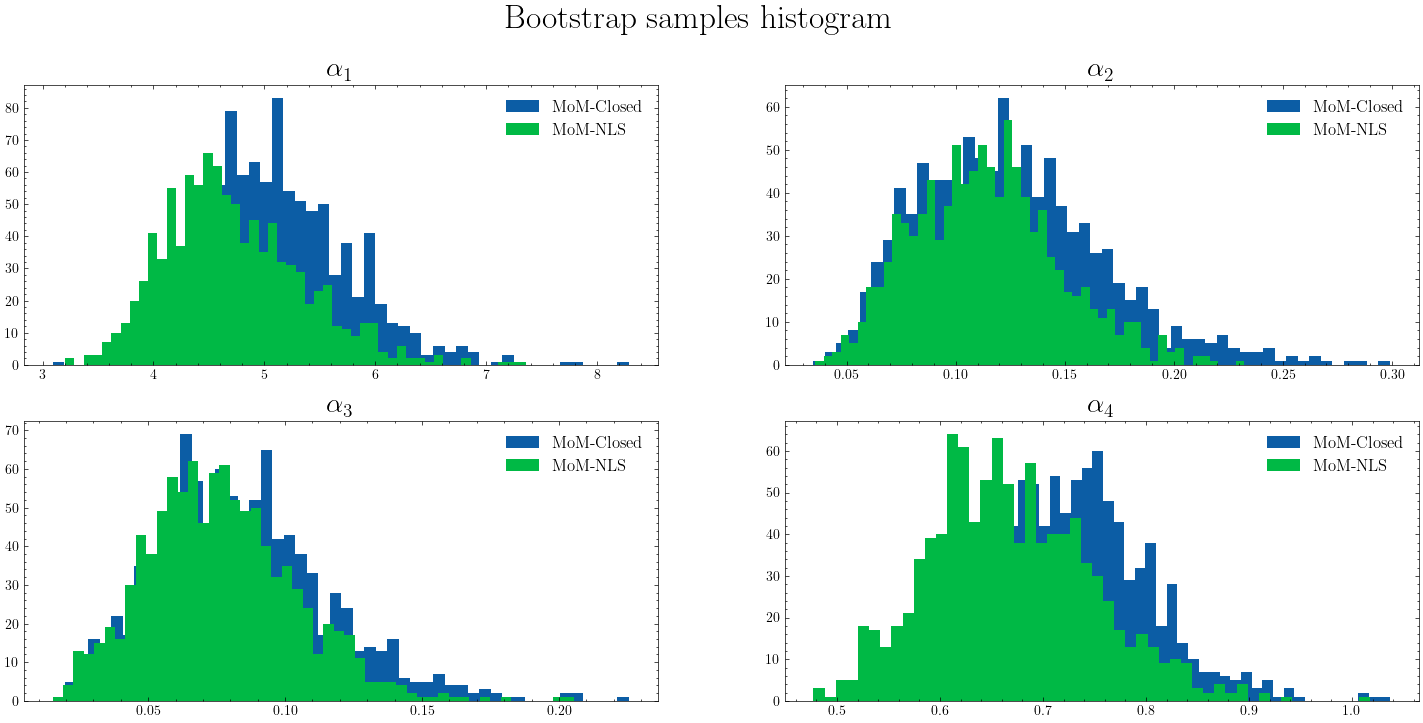

In [39]:
bootstrap_samples_1 = distribution.bootstrap_method(x, y, B=1000, method=distribution.method_moments_estimator_1)
bootstrap_samples_4 = distribution.bootstrap_method(x, y, B=1000, method=distribution.method_moments_estimator_4)

fig, ax = plt.subplots(2,2,figsize=(18,8))
fig.suptitle('Bootstrap samples histogram', fontsize=24)
for k in range(4):
    i = k // 2
    j = k % 2
    ax[i,j].hist(bootstrap_samples_1[k,:], bins=50, label='MoM-Closed')
    ax[i,j].hist(bootstrap_samples_4[k,:], bins=50, label='MoM-NLS')
    ax[i,j].set_title(r'$\alpha_{}$'.format(k+1), fontsize=20)
    ax[i,j].legend(fontsize=12)
plt.show()

In [40]:
a = np.array([1, 1, 1, 1])

data = {'n': x.shape[0], 'a': a, 'xy': np.column_stack([x, y]), 's_mu': 4, 's_sd': 1}
model_fit = model_lognormal.sample(data=data, iter_warmup=2000, iter_sampling=2000, chains=4, adapt_delta=0.9, seed=321321)

10:09:13 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

10:09:28 - cmdstanpy - INFO - CmdStan done processing.


In [41]:
idata = az.from_cmdstanpy(posterior=model_fit)
df = az.summary(idata, hdi_prob=0.95, stat_funcs={"median": np.median}).loc[[f'alpha[{i}]' for i in range(4)]]
df

/opt/homebrew/Caskroom/miniconda/base/envs/stan/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/homebrew/Caskroom/miniconda/base/envs/stan/lib/python3.11/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/opt/homebrew/Caskroom/miniconda/base/envs/stan/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/homebrew/Caskroom/miniconda/base/envs/stan/lib/python3.11/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/opt/homebrew/Caskroom/miniconda/base/envs/stan/lib/python3.11/site-packages/arviz/stats/diagnostics.p

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
alpha[0],4.797,0.459,3.924,5.700,0.005,0.005,6961.0,5966.0,1.0,4.787
alpha[1],0.139,0.011,0.118,0.162,0.000,0.000,6166.0,6474.0,1.0,0.139
alpha[2],0.126,0.010,0.106,0.146,0.000,0.000,6610.0,6492.0,1.0,0.125
alpha[3],0.712,0.059,0.598,0.830,0.001,0.001,7602.0,6391.0,1.0,0.710


In [42]:
az.bfmi(model_fit)

array([0.83241996, 0.77548906, 0.81352323, 0.84227819])

/opt/homebrew/Caskroom/miniconda/base/envs/stan/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


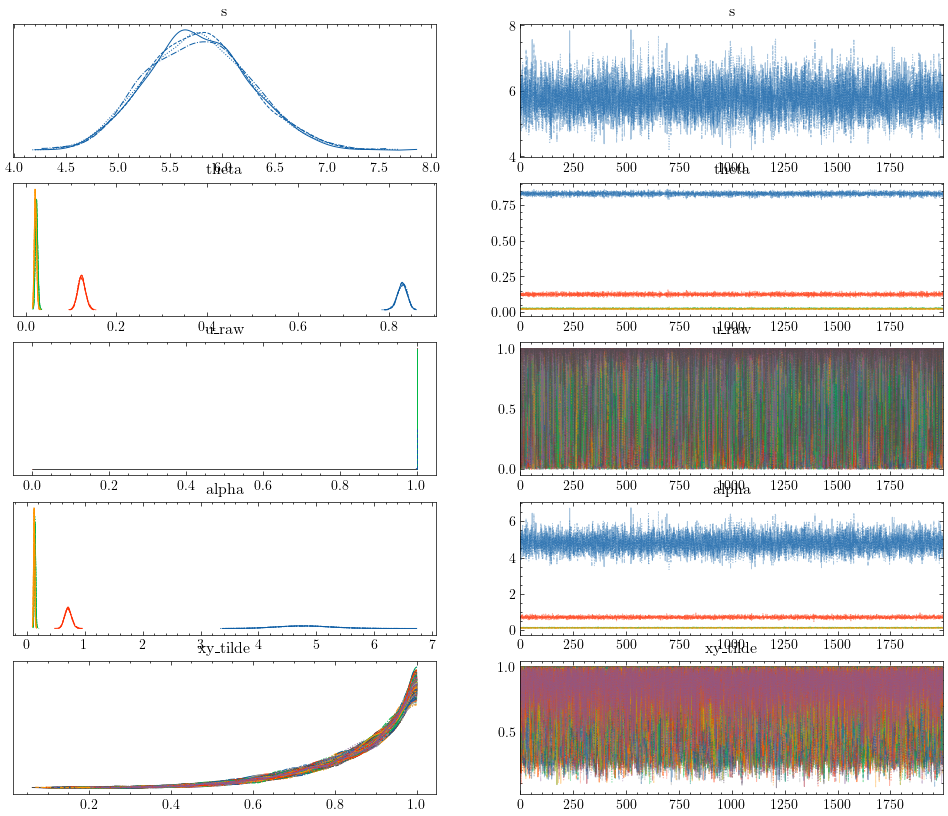

In [43]:
az.plot_trace(idata)
plt.show()

In [44]:
moments = np.zeros((model_fit.alpha.shape[0], 5))
for i in range(model_fit.alpha.shape[0]):
    moments[i,:] = BivariateBeta(model_fit.alpha[i,:]).moments()

In [45]:
moments.mean(axis=0)

array([0.85444914, 0.8520869 , 0.01848801, 0.01873615, 0.81550413])

In [46]:
np.median(moments, axis=0)

array([0.85482718, 0.85246067, 0.01833981, 0.01859033, 0.81609404])

In [47]:
from scipy.stats import gaussian_kde

def implied_moments_from_alpha(alpha):
    a1,a2,a3,a4 = alpha[:,0],alpha[:,1],alpha[:,2],alpha[:,3]
    s = a1+a2+a3+a4
    m1 = (a1+a2)/s; m2 = (a1+a3)/s
    v1 = ((a1+a2)*(a3+a4))/(s**2*(s+1))
    v2 = ((a1+a3)*(a2+a4))/(s**2*(s+1))
    rho = (a1*a4 - a2*a3)/np.sqrt((a1+a2)*(a3+a4)*(a1+a3)*(a2+a4))
    return {"m1":m1,"m2":m2,"v1":v1,"v2":v2,"rho":rho}

def observed_moments(x,y):
    m1=x.mean(); m2=y.mean()
    v1=np.mean((x-m1)**2); v2=np.mean((y-m2)**2)
    cov=np.mean((x-m1)*(y-m2)); rho=cov/np.sqrt(v1*v2)
    return {"m1":m1,"m2":m2,"v1":v1,"v2":v2,"rho":rho}

def _overlay_hist_hist_kde(ax, arr_closed, arr_nls, arr_bayes,
                           labels, colors, bins=30,
                           alpha_hist=0.35, lw=1.2):
    """Two stepfilled histograms (MoM-Closed, MoM-NLS) + KDE (Bayes)."""
    arrs = [arr_closed, arr_nls, arr_bayes]
    arrs = [a[np.isfinite(a)] for a in arrs]

    lo = min(a.min() for a in arrs if a.size)
    hi = max(a.max() for a in arrs if a.size)
    span = hi - lo
    pad = 0.05*span if span > 0 else 0.05
    xlo, xhi = lo - pad, hi + pad
    ax.set_xlim(xlo, xhi)

    ax.hist(arrs[0], bins=bins, density=True, histtype='stepfilled',
            color=colors[0], alpha=alpha_hist, edgecolor='black',
            linewidth=lw, label=labels[0])

    ax.hist(arrs[1], bins=bins, density=True, histtype='stepfilled',
            color=colors[1], alpha=alpha_hist, edgecolor='black',
            linewidth=lw, label=labels[1])

    if arrs[2].size:
        kde = gaussian_kde(arrs[2])
        xs = np.linspace(xlo, xhi, 512)
        ys = kde(xs)
        ax.fill_between(xs, 0, ys, color=colors[2], alpha=0.22, label=labels[2])
        ax.plot(xs, ys, color=colors[2], linewidth=1.8)

    ax.grid(True, ls=':', lw=0.6, alpha=0.3)
    ax.set_yticks([])

def plot_moment_distributions(bootstrap_closed, bootstrap_nls, alpha_post,
                                       x_obs, y_obs,
                                       colors=("#0072B2", "#009E73", "#CC79A7")):
    a_closed = np.asarray(bootstrap_closed).T
    a_nls    = np.asarray(bootstrap_nls).T
    a_post   = np.asarray(alpha_post)

    mom_closed = implied_moments_from_alpha(a_closed)
    mom_nls    = implied_moments_from_alpha(a_nls)
    mom_bayes  = implied_moments_from_alpha(a_post)
    obs        = observed_moments(x_obs, y_obs)

    stats  = ["m1","m2","v1","v2","rho"]
    titles = {"m1":r"$m_1$", "m2":r"$m_2$", "v1":r"$v_1$", "v2":r"$v_2$", "rho":r"$\rho$"}
    labels = ["MoM-Closed Bootstrap", "MoM-NLS Bootstrap", "Posterior distribution"]

    fig, axes = plt.subplots(1, 5, figsize=(12, 2.6), constrained_layout=True)
    for ax, k in zip(axes, stats):
        _overlay_hist_hist_kde(ax, mom_closed[k], mom_nls[k], mom_bayes[k],
                               labels, colors)
        ax.axvline(obs[k], color='red', lw=1.1, ls='--')
        ax.set_title(titles[k], fontsize=18)
        ax.tick_params(axis="x", labelsize=14)

    handles, labs = axes[0].get_legend_handles_labels()
    fig.legend(handles, labs, loc='lower center', ncol=3, frameon=False, fontsize=18,
               bbox_to_anchor=(0.5, -0.2))
    plt.savefig('../figures/caseA_ppc_moments.pdf', bbox_inches='tight')
    plt.show()

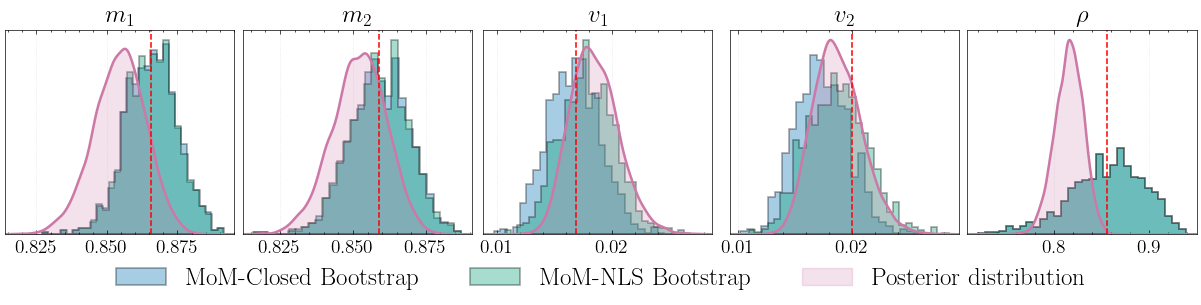

In [48]:
plot_moment_distributions(bootstrap_samples_1, bootstrap_samples_4, model_fit.alpha, x, y)

Fisher interval

In [49]:
import numpy as np

def fisher_z_ci(r, n, conf=0.95):
    r = np.asarray(r, dtype=float)
    if n <= 3:
        raise ValueError("n must be > 3 for Fisher-z interval.")
    # avoid atanh blow-up at boundaries
    r = np.clip(r, -0.999999, 0.999999)

    z = np.arctanh(r)
    se = 1.0 / np.sqrt(n - 3)
    alpha = 1.0 - conf

    try:
        from scipy.stats import norm
        zcrit = norm.ppf(1 - alpha / 2.0)
    except Exception:
        # fallback to standard 95% normal critical value
        zcrit = 1.959963984540054

    z_lo = z - zcrit * se
    z_hi = z + zcrit * se
    return np.tanh(z_lo), np.tanh(z_hi)

# --- Example (your case) ---
r_hat = 0.855
n = 195
lo, hi = fisher_z_ci(r_hat, n, conf=0.95)
print(f"Fisher-z 95% CI for rho: ({lo:.3f}, {hi:.3f})")  # ~ (0.812, 0.889)

Fisher-z 95% CI for rho: (0.812, 0.889)


Priors

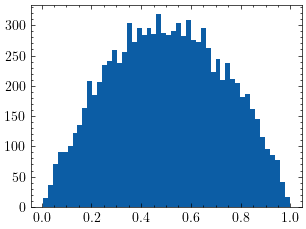

In [50]:
alpha_values = np.random.dirichlet((1,1,1,1), size=10000)
moments_implied = implied_moments_from_alpha(alpha_values)
plt.hist(moments_implied['m1'], bins=50)
plt.show()

## Comparing models

In [51]:
B_BOOT = 500

bln_boot_params, bln_boot_indices = bln_bootstrap_mle(model_logit, x, y, B=B_BOOT, seed=2032125)

BLN bootstrap (optimize):   0%|          | 0/500 [00:00<?, ?it/s]

10:10:07 - cmdstanpy - INFO - Chain [1] start processing
10:10:07 - cmdstanpy - INFO - Chain [1] done processing
10:10:07 - cmdstanpy - INFO - Chain [1] start processing
10:10:07 - cmdstanpy - INFO - Chain [1] done processing
10:10:07 - cmdstanpy - INFO - Chain [1] start processing
10:10:07 - cmdstanpy - INFO - Chain [1] done processing
10:10:07 - cmdstanpy - INFO - Chain [1] start processing
10:10:07 - cmdstanpy - INFO - Chain [1] done processing
10:10:07 - cmdstanpy - INFO - Chain [1] start processing
10:10:07 - cmdstanpy - INFO - Chain [1] done processing
10:10:07 - cmdstanpy - INFO - Chain [1] start processing
10:10:07 - cmdstanpy - INFO - Chain [1] done processing
10:10:07 - cmdstanpy - INFO - Chain [1] start processing
10:10:07 - cmdstanpy - INFO - Chain [1] done processing
10:10:07 - cmdstanpy - INFO - Chain [1] start processing
10:10:07 - cmdstanpy - INFO - Chain [1] done processing
10:10:07 - cmdstanpy - INFO - Chain [1] start processing
10:10:07 - cmdstanpy - INFO - Chain [1]

In [52]:
bln_fit = bln_bayes_sample(model_logit, x, y, chains=4, draws=2000, seed=2023215)

bln_idata = az.from_cmdstanpy(
    posterior=bln_fit,
    log_likelihood='log_lik',
    posterior_predictive='xy_tilde',
    coords={'obs_id': np.arange(len(x))},
    dims={'log_lik': ['obs_id'], 'xy_tilde': ['ppc_id', 'dim']},
)

10:10:52 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

10:10:56 - cmdstanpy - INFO - CmdStan done processing.
10:10:56 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: logit_bivariate_model_model_namespace::log_prob: Sigma is not symmetric. Sigma[1,2] = inf, but Sigma[2,1] = inf (in '/Users/lmm122/Documents/github/bivariate-beta/scripts/stan/logit-bivariate-model.stan', line 27, column 4 to column 24)
	Exception: logit_bivariate_model_model_namespace::log_prob: Sigma is not symmetric. Sigma[1,2] = -inf, but Sigma[2,1] = -inf (in '/Users/lmm122/Documents/github/bivariate-beta/scripts/stan/logit-bivariate-model.stan', line 27, column 4 to column 24)
	Exception: logit_bivariate_model_model_namespace::log_prob: Sigma is not symmetric. Sigma[1,2] = -inf, but Sigma[2,1] = -inf (in '/Users/lmm122/Documents/github/bivariate-beta/scripts/stan/logit-bivariate-model.stan', line 27, column 4 to column 24)
	Exception: logit_bivariate_model_model_namespace::log_prob: Sigma is not symmetric. Sigma[1,2] = inf, but Sigma[2,1] = inf (in '

In [55]:
obs_mom = sample_moments(x, y)
beta_moment_draws, beta_idata = beta_ppc_moments_from_model_fit(model_fit)

loo_res = az.loo(beta_idata, pointwise=True)
results = {}
results['beta_bayes'] = {
    'elpd': {
        'elpd_loo': float(loo_res.elpd_loo),
        'se': float(loo_res.se),
        'p_loo': float(loo_res.p_loo),
        'loo_i': loo_res.loo_i.values,
    },
    'moments': {},
}

results['beta_bayes']['moments']['Z'], \
results['beta_bayes']['moments']['mean'], \
results['beta_bayes']['moments']['sd'] = z_scores_from_moment_draws(beta_moment_draws, obs_mom)

# Tail distribution, Brier/Log scores
p_tail_draws = tail_from_posterior_predictive(beta_idata, thr=0.9, take=1000)
results['beta_bayes']['tail'] = {
    'p_mean': float(p_tail_draws.mean()),
    'p_sd':   float(p_tail_draws.std(ddof=1)),
    'p_draws': p_tail_draws,
}

/opt/homebrew/Caskroom/miniconda/base/envs/stan/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [56]:
bln_moment_draws = bln_ppc_moments_from_idata(bln_idata)

loo_res = az.loo(bln_idata, pointwise=True)
results['bln_bayes'] = {
    'elpd': {
        'elpd_loo': float(loo_res.elpd_loo),
        'se': float(loo_res.se),
        'p_loo': float(loo_res.p_loo),
        'loo_i': loo_res.loo_i.values,
    },
    'moments': {},
}

results['bln_bayes']['moments']['Z'], \
results['bln_bayes']['moments']['mean'], \
results['bln_bayes']['moments']['sd'] = z_scores_from_moment_draws(bln_moment_draws, obs_mom)

p_tail_draws_bln = tail_from_posterior_predictive(bln_idata, thr=0.9, take=1000)
results['bln_bayes']['tail'] = {
    'p_mean': float(p_tail_draws_bln.mean()),
    'p_sd':   float(p_tail_draws_bln.std(ddof=1)),
    'p_draws': p_tail_draws_bln,
}

In [57]:
mom_list = []
for a in bootstrap_samples_1.T:
    mom_list.append(BivariateBeta(a).moments())
mom_draws = np.asarray(mom_list, dtype=float)

mean_logscore_bibeta, loo_scores_bibeta = loo_logscore_bibeta(x, y, distribution.method_moments_estimator_1, seed=654321, T=20000, nu=1e-8)
results['mom_closed'] = {
    'elpd': {
        'elpd_loo': float(loo_scores_bibeta.sum()),
        'se': float(loo_scores_bibeta.std(ddof=1) / np.sqrt(len(loo_scores_bibeta))),
        'p_loo': None,
        'loo_i': loo_scores_bibeta,
    },
    'moments': {},
}

Z, mu_mom, sd_mom = z_scores_from_moment_draws(mom_draws, obs_mom)
results['mom_closed']['moments'] = {'Z': Z, 'mean': mu_mom, 'sd': sd_mom}

p_tail_draws_m1 = tail_from_bibeta_bootstrap(bootstrap_samples_1.T, thr=0.9, T=40000, take=1000)
results['mom_closed']['tail'] = {
    'p_mean': float(p_tail_draws_m1.mean()),
    'p_sd':   float(p_tail_draws_m1.std(ddof=1)),
    'p_draws': p_tail_draws_m1,
}

  0%|          | 0/195 [00:00<?, ?it/s]

Tail from Beta bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

In [58]:
mom_list = []
for a in bootstrap_samples_4.T:
    mom_list.append(BivariateBeta(a).moments())
mom_draws = np.asarray(mom_list, dtype=float)

mean_logscore_bibeta, loo_scores_bibeta = loo_logscore_bibeta(x, y, distribution.method_moments_estimator_4, seed=654321)
results['mom_nls'] = {
    'elpd': {
        'elpd_loo': float(loo_scores_bibeta.sum()),
        'se': float(loo_scores_bibeta.std(ddof=1) / np.sqrt(len(loo_scores_bibeta))),
        'p_loo': None,
        'loo_i': loo_scores_bibeta,
    },
    'moments': {},
}

Z, mu_mom, sd_mom = z_scores_from_moment_draws(mom_draws, obs_mom)
results['mom_nls']['moments'] = {'Z': Z, 'mean': mu_mom, 'sd': sd_mom}

p_tail_draws_m4 = tail_from_bibeta_bootstrap(bootstrap_samples_4.T, thr=0.9, T=40000, take=1000)
results['mom_nls']['tail'] = {
    'p_mean': float(p_tail_draws_m4.mean()),
    'p_sd':   float(p_tail_draws_m4.std(ddof=1)),
    'p_draws': p_tail_draws_m4,
}

  0%|          | 0/195 [00:00<?, ?it/s]

Tail from Beta bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

In [65]:
mle_list = []
for a in bln_boot_params:
    mle_list.append(bln_moments(mu1=a[0], mu2=a[1], sigma1=a[2], sigma2=a[3], rho=a[4]))
mle_draws = np.asarray(mle_list, dtype=float)

mean_logscore_bln, loo_scores_bln = loo_logscore_bln(x, y, model_logit, seed=654321, B=10)
results['mle'] = {
    'elpd': {
        'elpd_loo': float(loo_scores_bln.sum()),
        'se': float(loo_scores_bln.std(ddof=1) / np.sqrt(len(loo_scores_bln))),
        'p_loo': None,
        'loo_i': loo_scores_bln,
    },
    'moments': {},
}

Z, mu_mle, sd_mle = z_scores_from_moment_draws(mle_draws, obs_mom)
results['mle']['moments'] = {'Z': Z, 'mean': mu_mle, 'sd': sd_mle}

p_tail_draws = tail_from_bln_bootstrap(bln_boot_params, thr=0.9, T=40000, take=1000)
results['mle']['tail'] = {
    'p_mean': float(p_tail_draws.mean()),
    'p_sd':   float(p_tail_draws.std(ddof=1)),
    'p_draws': p_tail_draws,
}

  0%|          | 0/195 [00:00<?, ?it/s]

10:37:39 - cmdstanpy - INFO - Chain [1] start processing
10:37:39 - cmdstanpy - INFO - Chain [1] done processing
10:37:39 - cmdstanpy - INFO - Chain [1] start processing
10:37:39 - cmdstanpy - INFO - Chain [1] done processing
10:37:39 - cmdstanpy - INFO - Chain [1] start processing
10:37:39 - cmdstanpy - INFO - Chain [1] done processing
10:37:39 - cmdstanpy - INFO - Chain [1] start processing
10:37:39 - cmdstanpy - INFO - Chain [1] done processing
10:37:39 - cmdstanpy - INFO - Chain [1] start processing
10:37:39 - cmdstanpy - INFO - Chain [1] done processing
10:37:39 - cmdstanpy - INFO - Chain [1] start processing
10:37:39 - cmdstanpy - INFO - Chain [1] done processing
10:37:39 - cmdstanpy - INFO - Chain [1] start processing
10:37:39 - cmdstanpy - INFO - Chain [1] done processing
10:37:39 - cmdstanpy - INFO - Chain [1] start processing
10:37:39 - cmdstanpy - INFO - Chain [1] done processing
10:37:39 - cmdstanpy - INFO - Chain [1] start processing
10:37:39 - cmdstanpy - INFO - Chain [1]

Tail from BLN bootstrap:   0%|          | 0/500 [00:00<?, ?it/s]

In [66]:
ind_tail = tail_event_indicators(x, y, thr=0.9).astype(int)

def summarize_brier_log(name, p_draws_or_scalar):
    # use mean p (Bayes) or scalar; Brier/log scores against empirical indicators
    if np.ndim(p_draws_or_scalar) == 0:
        p = float(p_draws_or_scalar)
        b,l = brier_log_scores(ind_tail, p)
        return {'p': p, 'brier': b, 'logscore': l}
    else:
        p_mean = float(np.mean(p_draws_or_scalar))
        b,l = brier_log_scores(ind_tail, p_mean)
        return {'p': p_mean, 'brier': b, 'logscore': l}

summary_rows = []
s = summarize_brier_log('beta_bayes', results['beta_bayes']['tail']['p_draws'])
summary_rows.append(['beta_bayes', s['p'], s['brier'], s['logscore']])

s = summarize_brier_log('bln_bayes', results['bln_bayes']['tail']['p_draws'])
summary_rows.append(['bln_bayes', s['p'], s['brier'], s['logscore']])

s = summarize_brier_log('mom_closed', results['mom_closed']['tail']['p_draws'])
summary_rows.append(['mom_closed', s['p'], s['brier'], s['logscore']])

s = summarize_brier_log('mom_nls', results['mom_nls']['tail']['p_draws'])
summary_rows.append(['mom_nls', s['p'], s['brier'], s['logscore']])

s = summarize_brier_log('mle', results['mle']['tail']['p_draws'])
summary_rows.append(['mle', s['p'], s['brier'], s['logscore']])

summary_df = pd.DataFrame(summary_rows, columns=['model','p_tail','brier','logscore'])
print("Tail-event summary (p_hat, Brier, Log-score):")
display(summary_df)

Tail-event summary (p_hat, Brier, Log-score):


,model,p_tail,brier,logscore
0,beta_bayes,0.415267,0.244578,-0.682269
1,bln_bayes,0.449908,0.245060,-0.683242
2,mom_closed,0.453951,0.245272,-0.683671
3,mom_nls,0.464645,0.245992,-0.685120
4,mle,0.456658,0.245433,-0.683995


In [67]:
elpd_rows = []
elpd_rows.append(['beta_bayes', results['beta_bayes']['elpd']['elpd_loo'], results['beta_bayes']['elpd']['se']])
elpd_rows.append(['bln_bayes', results['bln_bayes']['elpd']['elpd_loo'], results['bln_bayes']['elpd']['se']])
elpd_rows.append(['mom_closed', results['mom_closed']['elpd']['elpd_loo'], results['mom_closed']['elpd']['se']])
elpd_rows.append(['mom_nls', results['mom_nls']['elpd']['elpd_loo'], results['mom_nls']['elpd']['se']])
elpd_rows.append(['mle', results['mle']['elpd']['elpd_loo'], results['mle']['elpd']['se']])
elpd_df = pd.DataFrame(elpd_rows, columns=['model','elpd','elpd_se'])
print("ELPD (Bayes PSIS-LOO and Freq bootstrap-LOO):")
display(elpd_df)

ELPD (Bayes PSIS-LOO and Freq bootstrap-LOO):


,model,elpd,elpd_se
0,beta_bayes,1688.106048,151.685496
1,bln_bayes,497.355119,28.808102
2,mom_closed,587.466237,0.326253
3,mom_nls,562.196132,0.316187
4,mle,485.282036,0.150207


In [68]:
def pack_z(model_key, label):
    if model_key not in results: 
        return None
    Z = results[model_key]['moments']['Z']
    mu = results[model_key]['moments']['mean']
    sd = results[model_key]['moments']['sd']
    cols = ['m1','m2','v1','v2','rho']
    row = [label] + list(Z)
    return row, cols

z_rows = []
for key,label in [('beta_bayes','beta_bayes'), ('bln_bayes','bln_bayes'),
                  ('mom_closed','mom_closed'), ('mom_nls','mom_nls'), ('mle', 'mle')]:
    out = pack_z(key, label)
    if out: z_rows.append(out[0]); cols = out[1]
if z_rows:
    z_df = pd.DataFrame(z_rows, columns=['model'] + cols)
    print("Standardized moment misfit Z-scores (observed vs model-implied):")
    display(z_df)

Standardized moment misfit Z-scores (observed vs model-implied):


,model,m1,m2,v1,v2,rho
0,beta_bayes,0.814693,0.493140,-0.459550,0.396180,0.752021
1,bln_bayes,0.012843,0.016815,-0.477798,-0.314833,1.500937
2,mom_closed,-0.025921,-0.019465,0.062464,1.080882,-0.015693
3,mom_nls,-0.040942,-0.005914,-0.423507,0.491217,-0.015704
4,mle,0.418248,0.418815,-0.478641,-0.463765,0.307949


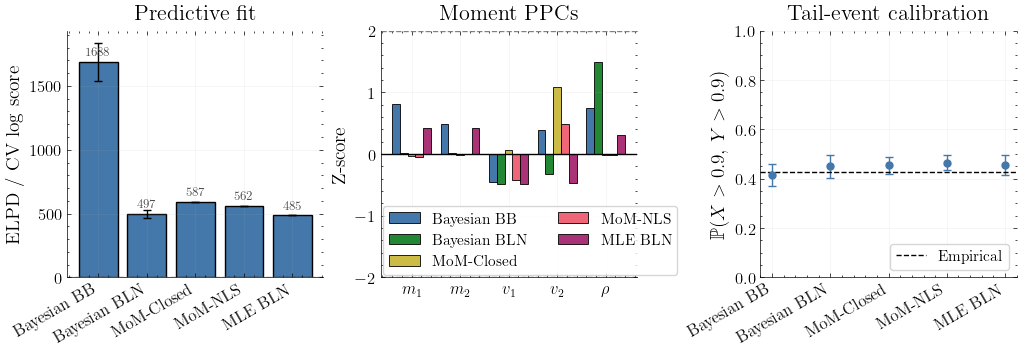

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

# -------------------- styling (paper-friendly) --------------------
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.15,
    "grid.linestyle": "-",
})

# Colorblind-friendly palette (Tol's "bright")
COLORS = ["#4477AA", "#228833", "#CCBB44", "#EE6677", "#AA3377"]

# -------------------- model order & labels --------------------
models = OrderedDict([
    ("beta_bayes", "Bayesian BB"),     # rename here if you prefer another label
    ("bln_bayes",  "Bayesian BLN"),
    ("mom_closed", "MoM-Closed"),
    ("mom_nls",    "MoM-NLS"),
    ("mle",        "MLE BLN"),
])
methods = list(models.values())
xpos = np.arange(len(methods))

# -------------------- pull numbers from your `results` --------------------
elpd_means = [float(results[k]['elpd']['elpd_loo']) for k in models.keys()]
elpd_se    = [float(results[k]['elpd']['se'])       for k in models.keys()]

moment_labels = [r"$m_1$", r"$m_2$", r"$v_1$", r"$v_2$", r"$\rho$"]
moments = { models[k]: np.asarray(results[k]['moments']['Z'], float) for k in models.keys() }

tail_mean = [float(results[k]['tail']['p_mean']) for k in models.keys()]
tail_sd   = [float(results[k]['tail']['p_sd'])   for k in models.keys()]
empirical_tail = float(np.mean((x > 0.9) & (y > 0.9)))

# -------------------- figure --------------------
fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.5), constrained_layout=True)

# ========== Panel 1: Predictive fit ==========
ax = axes[0]
bars = ax.bar(
    xpos, elpd_means, yerr=elpd_se, capsize=3, linewidth=1.0,
    edgecolor="black", color=COLORS[0]
)
ax.axhline(0, color="0.5", linestyle="--", linewidth=1)
ax.set_xticks(xpos)
ax.set_xticklabels(methods, rotation=30, ha="right")
ax.set_ylabel("ELPD / CV log score")
ax.set_title("Predictive fit", pad=8)

# lightly annotate bars (optional; comment out if you prefer clean bars)
for rect in bars:
    ax.annotate(f"{rect.get_height():.0f}",
                xy=(rect.get_x() + rect.get_width()/2, rect.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, color="0.3")

# ========== Panel 2: Moment PPC Z-scores ==========
ax = axes[1]
width = 0.16
for j, method in enumerate(methods):
    zvals = moments[method]
    ax.bar(np.arange(len(moment_labels)) + j*width, zvals,
           width=width, label=method, color=COLORS[j], edgecolor="black", linewidth=0.6)
ax.axhline(0, color="black", linewidth=1)
ax.axhline(2, color="0.5", linestyle="--", linewidth=1)
ax.axhline(-2, color="0.5", linestyle="--", linewidth=1)
ax.set_xticks(np.arange(len(moment_labels)) + 2*width)
ax.set_xticklabels(moment_labels)
ax.set_ylabel("Z-score")
ax.set_title("Moment PPCs", pad=8)
ax.legend(ncol=2, frameon=True, loc="lower left", bbox_to_anchor=(-0.02, -0.02))

# Set a reasonable y-range if extreme MoM Z's appear
z_all = np.concatenate([moments[m] for m in methods])
z_lim = np.percentile(np.abs(z_all), 98)  # robust
ax.set_ylim(-max(2, z_lim), max(2, z_lim))

# ========== Panel 3: Tail-event calibration ==========
ax = axes[2]
ax.errorbar(xpos, tail_mean, yerr=tail_sd, fmt="o", ms=5,
            elinewidth=1.0, capsize=3, color=COLORS[0])
ax.axhline(empirical_tail, color="black", linestyle="--", linewidth=1, label="Empirical")
ax.set_xticks(xpos)
ax.set_xticklabels(methods, rotation=30, ha="right")
ax.set_ylabel(r"$\mathbb{P}(X > 0.9,\, Y > 0.9)$")
# auto y-limits with a little padding
lo = min(min(tail_mean) - 2*max(tail_sd), 0.0)
hi = max(max(tail_mean) + 2*max(tail_sd), 1.0)
ax.set_ylim(max(0.0, lo), min(1.0, hi))
ax.set_title("Tail-event calibration", pad=8)
ax.legend(frameon=True, loc="lower right")

# -------------------- save (vector + raster) --------------------
plt.savefig("../figures/caseA_comparinson.pdf", bbox_inches="tight")
plt.show()

# US Politics

In [144]:
df2016 = pd.read_csv('../data/US_County_Level_Election_Results_08-24-master/2016_US_County_Level_Presidential_Results.csv', index_col=0)
df2020 = pd.read_csv('../data/US_County_Level_Election_Results_08-24-master/2020_US_County_Level_Presidential_Results.csv')
df2024 = pd.read_csv('../data/US_County_Level_Election_Results_08-24-master/2024_US_County_Level_Presidential_Results.csv')

df2016['county_fips'] = df2016['combined_fips'].astype(int)
df2020['county_fips'] = df2020['county_fips'].astype(int)
df2024['county_fips'] = df2024['county_fips'].astype(int)
    
df2016 = df2016[df2016['county_fips'] % 1000 != 0] 
df2020 = df2020[df2020['county_fips'] % 1000 != 0] 
df2024 = df2024[df2024['county_fips'] % 1000 != 0]

df2016 = df2016[df2016['votes_dem'].fillna(0) + df2016['votes_gop'].fillna(0) > 0]
df2020 = df2020[df2020['votes_dem'].fillna(0) + df2020['votes_gop'].fillna(0) > 0]
df2024 = df2024[df2024['votes_dem'].fillna(0) + df2024['votes_gop'].fillna(0) > 0]

df2016 = df2016[df2016['county_name'] != 'Alaska']

df2020 = df2020.groupby('county_fips', as_index=False)[['votes_dem','votes_gop']].sum()
df2024 = df2024.groupby('county_fips', as_index=False)[['votes_dem','votes_gop']].sum()

In [145]:
df_merge = pd.merge(df2020, df2024, on='county_fips', suffixes=('_20','_24'), how='inner')
df_merge['share_dem_20'] = df_merge['votes_dem_20']/(df_merge['votes_dem_20'] + df_merge['votes_gop_20'])
df_merge['share_dem_24'] = df_merge['votes_dem_24']/(df_merge['votes_dem_24'] + df_merge['votes_gop_24'])
df_merge.drop(columns=['votes_dem_20', 'votes_gop_20', 'votes_dem_24', 'votes_gop_24'], inplace=True)
df_merge.set_index('county_fips', inplace=True)

In [146]:
df_merge

,share_dem_20,share_dem_24
county_fips,,
1001,0.274423,0.266411
1003,0.227317,0.206524
1005,0.461391,0.425850
1007,0.208811,0.176151
1009,0.096523,0.092231
...,...,...
56037,0.238163,0.229290
56039,0.694059,0.679087
56041,0.175085,0.176524


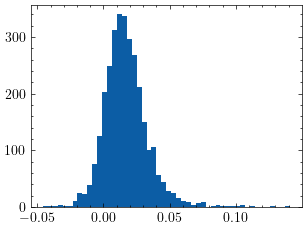

In [147]:
plt.hist(df_merge['share_dem_20']-df_merge['share_dem_24'], bins=50)
plt.show()

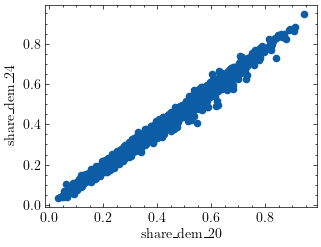

In [148]:
df_merge.plot(kind='scatter', x='share_dem_20', y='share_dem_24')
plt.show()

In [168]:
df_merge.mean()

share_dem_20    0.338315
share_dem_24    0.321273
dtype: float64

In [169]:
df_merge.corr()

,share_dem_20,share_dem_24
share_dem_20,1.000000,0.994991
share_dem_24,0.994991,1.000000


In [170]:
a = np.array([1, 1, 1, 1])

data = {'n': x.shape[0], 'a': a, 'xy': np.column_stack([x, y]), 's_mu': 4, 's_sd': 1}
model_fit = model_lognormal.sample(data=data, iter_warmup=2000, iter_sampling=2000, chains=4, adapt_delta=0.9)

12:17:29 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

12:17:44 - cmdstanpy - INFO - CmdStan done processing.


In [171]:
idata = az.from_cmdstanpy(posterior=model_fit)
df = az.summary(idata, hdi_prob=0.95, stat_funcs={"median": np.median})
df

/opt/homebrew/Caskroom/miniconda/base/envs/stan/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/homebrew/Caskroom/miniconda/base/envs/stan/lib/python3.11/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/opt/homebrew/Caskroom/miniconda/base/envs/stan/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/homebrew/Caskroom/miniconda/base/envs/stan/lib/python3.11/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
s,5.768,0.502,4.768,6.732,0.008,0.005,4243.0,5347.0,1.0,5.757
theta[0],0.830,0.011,0.810,0.851,0.000,0.000,6037.0,5360.0,1.0,0.831
theta[1],0.024,0.003,0.019,0.030,0.000,0.000,4525.0,5503.0,1.0,0.024
theta[2],0.022,0.002,0.017,0.027,0.000,0.000,3860.0,5556.0,1.0,0.022
theta[3],0.124,0.008,0.106,0.139,0.000,0.000,7273.0,5557.0,1.0,0.123
...,...,...,...,...,...,...,...,...,...,...
u_raw[194],0.955,0.129,0.734,1.000,0.001,0.004,6529.0,6996.0,1.0,0.999
alpha[0],4.792,0.460,3.924,5.728,0.007,0.005,4278.0,5239.0,1.0,4.783
alpha[1],0.139,0.011,0.117,0.161,0.000,0.000,5653.0,6476.0,1.0,0.139
alpha[2],0.126,0.010,0.105,0.147,0.000,0.000,5303.0,6533.0,1.0,0.126


In [172]:
moments = np.zeros((model_fit.alpha.shape[0], 5))
for i in range(model_fit.alpha.shape[0]):
    moments[i,:] = BivariateBeta(model_fit.alpha[i,:]).moments()

In [173]:
moments.mean(axis=0)

array([0.85449474, 0.85218429, 0.01850073, 0.01874375, 0.81524642])